# 05 · Product, Category and Reorder Analysis

**Phases 7, 8 and 9 of the brief.** Which products and categories matter, and what drives
repeat purchase?

One measurement decision governs this whole notebook. **Reorder rate on a product with 12
purchases is noise.** A product bought twice, once as a repeat, shows a 50% reorder rate
and tells us nothing. So every reorder-rate *ranking* here carries a minimum-volume
threshold, and the threshold is always stated. Rankings without one are a standard way to
produce confident nonsense.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import instacart as ic, analysis as an
plt = ic.set_style()
pd.set_option("display.width", 190, "display.max_columns", 40, "display.max_colwidth", 46)

prods, aisles, depts = ic.load_lookups()
customers = ic.load_clean("customers")
orders = ic.load_clean("orders_clean")
items = ic.load_clean("order_items", columns=["order_id","user_id","product_uid","reordered",
                                              "add_to_cart_order","order_number","aisle_id","department_id"])
print(f"{len(items):,} basket lines | {items.product_uid.nunique():,} distinct products purchased")

33,819,106 basket lines | 49,573 distinct products purchased


## 5.1 Phase 7.1 — Top products

In [2]:
pk = an.product_kpis(items, prods); ic.savetable(pk, "product_kpis")
cols = ["product_name","department","purchases","n_customers","reorders","reorder_rate","mean_cart_position"]
print("TOP 10 BY PURCHASE VOLUME")
display(pk.head(10)[cols].style.format({"purchases":"{:,.0f}","n_customers":"{:,.0f}","reorders":"{:,.0f}",
        "reorder_rate":"{:.1%}","mean_cart_position":"{:.1f}"}).hide(axis="index"))
print("TOP 10 BY NUMBER OF REORDERS")
display(pk.nlargest(10,"reorders")[cols].style.format({"purchases":"{:,.0f}","n_customers":"{:,.0f}",
        "reorders":"{:,.0f}","reorder_rate":"{:.1%}","mean_cart_position":"{:.1f}"}).hide(axis="index"))

  table  -> reports/tables/product_kpis.csv  (49,573 rows)
TOP 10 BY PURCHASE VOLUME


product_name,department,purchases,n_customers,reorders,reorder_rate,mean_cart_position
Banana,produce,"491,291","76,125","415,166",84.5%,4.9
Bag of Organic Bananas,produce,"394,930","65,655","329,275",83.4%,5.1
Organic Strawberries,produce,"275,577","61,129","214,448",77.8%,7.3
Organic Baby Spinach,produce,"251,705","56,766","194,939",77.4%,7.4
Organic Hass Avocado,produce,"220,877","44,704","176,173",79.8%,6.8
Organic Avocado,produce,"184,224","43,954","140,270",76.1%,6.4
Large Lemon,produce,"160,792","48,614","112,178",69.8%,8.0
Organic Whole Milk,dairy eggs,"152,915","25,048","127,178",83.2%,5.4
Strawberries,produce,"149,445","44,857","104,588",70.0%,7.1
Limes,produce,"146,660","46,658","100,002",68.2%,8.6


TOP 10 BY NUMBER OF REORDERS


product_name,department,purchases,n_customers,reorders,reorder_rate,mean_cart_position
Banana,produce,"491,291","76,125","415,166",84.5%,4.9
Bag of Organic Bananas,produce,"394,930","65,655","329,275",83.4%,5.1
Organic Strawberries,produce,"275,577","61,129","214,448",77.8%,7.3
Organic Baby Spinach,produce,"251,705","56,766","194,939",77.4%,7.4
Organic Hass Avocado,produce,"220,877","44,704","176,173",79.8%,6.8
Organic Avocado,produce,"184,224","43,954","140,270",76.1%,6.4
Organic Whole Milk,dairy eggs,"152,915","25,048","127,178",83.2%,5.4
Large Lemon,produce,"160,792","48,614","112,178",69.8%,8.0
Organic Raspberries,produce,"142,603","32,915","109,688",76.9%,7.2
Strawberries,produce,"149,445","44,857","104,588",70.0%,7.1


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


  figure -> reports/figures/05_top_products.png


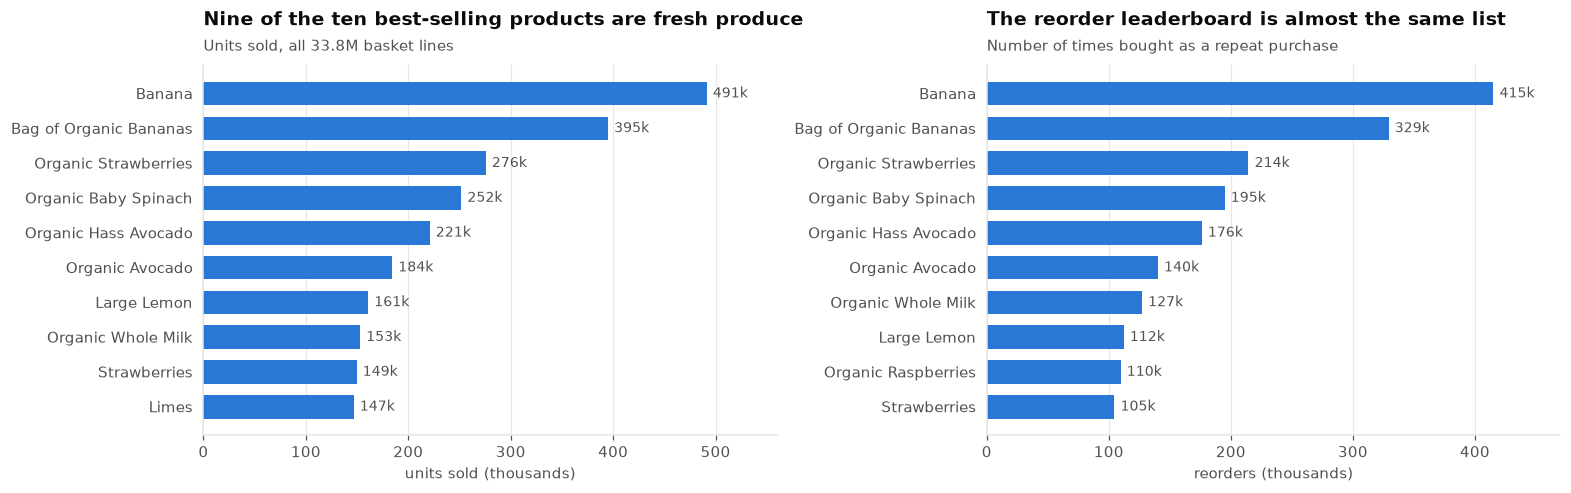

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14.4, 4.6))
t = pk.head(10).iloc[::-1]
axes[0].barh(t.product_name, t.purchases/1000, color=ic.PALETTE["s1"], height=.68)
for i, v in enumerate(t.purchases/1000):
    axes[0].text(v+6, i, f"{v:.0f}k", va="center", fontsize=9, color=ic.PALETTE["muted"])
ic.finish(axes[0], "Nine of the ten best-selling products are fresh produce",
          "Units sold, all 33.8M basket lines", "units sold (thousands)", "", xgrid=True)
axes[0].set_xlim(0, 560)

t2 = pk.nlargest(10,"reorders").iloc[::-1]
axes[1].barh(t2.product_name, t2.reorders/1000, color=ic.PALETTE["s1"], height=.68)
for i, v in enumerate(t2.reorders/1000):
    axes[1].text(v+5, i, f"{v:.0f}k", va="center", fontsize=9, color=ic.PALETTE["muted"])
ic.finish(axes[1], "The reorder leaderboard is almost the same list",
          "Number of times bought as a repeat purchase", "reorders (thousands)", "", xgrid=True)
axes[1].set_xlim(0, 470)
fig.tight_layout(); ic.savefig(fig, "05_top_products"); plt.show()

**Finding.** Bananas are the single best-selling product (**491,291 units**, bought by
76,125 customers — 37% of all customers), followed by organic bananas (394,930). Nine of the
top ten are fresh produce; the tenth is organic whole milk.

The second panel matters more than it looks: **the top-volume list and the top-reorder list
are nearly identical.** These products are not big because lots of people try them once —
they are big because the same people buy them again and again. Bananas have an 84.5%
reorder rate at half a million units, which is the rarest combination in the dataset.

### Products with the highest reorder rate — and why the threshold matters

Here is the trap, shown rather than described:

In [4]:
print("Top 10 'highest reorder rate' with NO minimum volume:")
display(pk.nlargest(10,"reorder_rate")[["product_name","department","purchases","n_customers","reorder_rate"]]
        .style.format({"purchases":"{:,.0f}","n_customers":"{:,.0f}","reorder_rate":"{:.1%}"}).hide(axis="index"))
print("\nThese are products bought a handful of times by one or two people. The ranking is noise.")

Top 10 'highest reorder rate' with NO minimum volume:


product_name,department,purchases,n_customers,reorder_rate
Raw Veggie Wrappers,deli,69,4,94.2%
Serenity Ultimate Extrema Overnight Pads,personal care,90,6,93.3%
Orange Energy Shots,beverages,13,1,92.3%
Chocolate Love Bar,snacks,102,8,92.2%
Soy Powder Infant Formula,babies,35,3,91.4%
Simply Sleep Nighttime Sleep Aid,other,45,4,91.1%
"Energy Shot, Grape Flavor",beverages,22,2,90.9%
Russian River Valley Reserve Pinot Noir,alcohol,30,3,90.0%
Bars Peanut Butter,pantry,69,7,89.9%
Soy Crisps Lightly Salted,snacks,67,7,89.6%



These are products bought a handful of times by one or two people. The ranking is noise.


In [5]:
for mp in (100, 2000):
    print(f"\nTop 10 reorder rate, minimum {mp:,} purchases ({(pk.purchases>=mp).sum():,} products qualify):")
    display(pk[pk.purchases>=mp].nlargest(10,"reorder_rate")[["product_name","department","purchases","n_customers","reorder_rate"]]
            .style.format({"purchases":"{:,.0f}","n_customers":"{:,.0f}","reorder_rate":"{:.1%}"}).hide(axis="index"))


Top 10 reorder rate, minimum 100 purchases (20,436 products qualify):


product_name,department,purchases,n_customers,reorder_rate
Chocolate Love Bar,snacks,102,8,92.2%
Maca Buttercups,snacks,104,11,89.4%
Benchbreak Chardonnay,alcohol,111,12,89.2%
Fragrance Free Clay with Natural Odor Eliminator Cat Litter,pets,131,17,87.0%
Thousand Island Salad Snax,snacks,114,15,86.8%
Real2 Alkalized Water 500 ml,beverages,457,63,86.2%
Half And Half Ultra Pasteurized,dairy eggs,"2,995",415,86.1%
Whole Organic Omega 3 Milk,dairy eggs,"9,410","1,319",86.0%
Lo-Carb Energy Drink,beverages,484,68,86.0%
Organic Lactose Free Whole Milk,dairy eggs,"8,742","1,231",85.9%



Top 10 reorder rate, minimum 2,000 purchases (2,915 products qualify):


product_name,department,purchases,n_customers,reorder_rate
Half And Half Ultra Pasteurized,dairy eggs,"2,995",415,86.1%
Whole Organic Omega 3 Milk,dairy eggs,"9,410","1,319",86.0%
Organic Lactose Free Whole Milk,dairy eggs,"8,742","1,231",85.9%
Organic Homogenized Whole Milk,dairy eggs,"4,095",581,85.8%
"Milk, Organic, Vitamin D",dairy eggs,"20,770","3,017",85.5%
Organic Reduced Fat Milk,dairy eggs,"36,869","5,475",85.2%
Goat Milk,dairy eggs,"5,353",802,85.0%
Banana,produce,"491,291","76,125",84.5%
Organic Lowfat 1% Milk,dairy eggs,"15,352","2,438",84.1%
Organic Reduced Fat Omega-3 Milk,dairy eggs,"5,299",854,83.9%


**Finding.** With a sensible threshold the answer is unambiguous and commercially
meaningful: **the most-reordered products in the catalogue are milk and yogurt**. Nine of
the top ten products at a 2,000-purchase threshold are milk variants (85.9% down to 83.9%),
and the only non-dairy entry in the list is the banana.

**Business meaning.** These are not products people *choose* — they are products people
*run out of*. The reorder rate is measuring consumption cadence, not preference. That makes
this list the natural seed for a subscription or auto-replenishment offer: the behaviour
already exists, and the product is only asking the customer to stop re-typing it.

## 5.2 Phase 7.2 — Purchase volume vs reorder rate

*The brief asks to separate products that are merely popular from products that earn
loyalty.* Volume and reorder rate measure different things and a product can be strong on
either, both, or neither. Plotting them against each other makes the four strategies visible.

Thresholds: only products with **≥ 500 purchases** are plotted (8,563 of 49,573), and the
split is at the **median of that pool** — volume 1,287 units, reorder rate 54.6% — rather
than at a round number chosen to make the story work.

In [6]:
q = an.volume_vs_reorder_quadrants(pk, 500); ic.savetable(q, "product_quadrants")
vmed, rmed = q.attrs["volume_median"], q.attrs["reorder_median"]
summary = q.groupby("quadrant").agg(products=("product_uid","size"), units=("purchases","sum"),
                                    avg_reorder_rate=("reorder_rate","mean"),
                                    customers=("n_customers","mean"))
summary["share of the 30.1M units in this pool"] = summary.units/summary.units.sum()
display(summary.style.format({"products":"{:,.0f}","units":"{:,.0f}","avg_reorder_rate":"{:.1%}",
                              "customers":"{:,.0f}","share of the 30.1M units in this pool":"{:.1%}"}))

  table  -> reports/tables/product_quadrants.csv  (8,563 rows)


,products,units,avg_reorder_rate,customers,share of the 30.1M units in this pool
quadrant,,,,,
Core staples (high volume + high loyalty),"2,537","20,355,921",64.8%,"2,579",67.5%
"Long tail (low volume, low loyalty)","2,535","2,001,570",40.7%,468,6.6%
"Loyal niche (low volume, high loyalty)","1,746","1,424,112",62.9%,302,4.7%
"Traffic drivers (high volume, low loyalty)","1,745","6,369,628",43.4%,"2,016",21.1%


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


  figure -> reports/figures/05_volume_vs_reorder.png


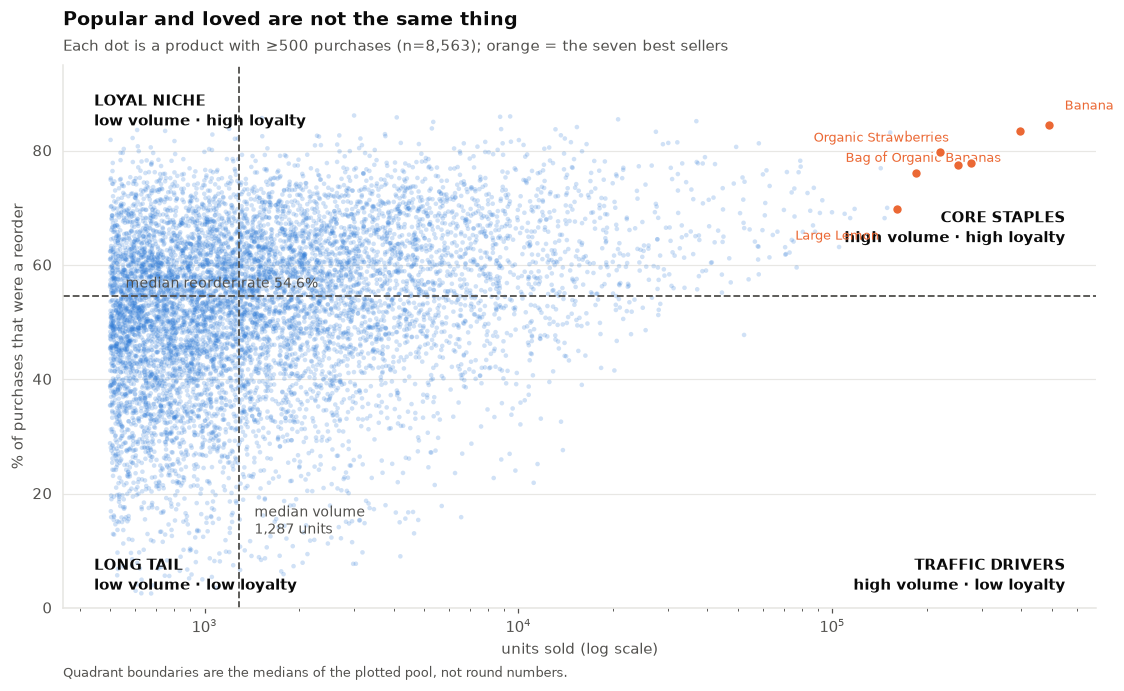

In [7]:
fig, ax = plt.subplots(figsize=(10.4, 6.4))
ax.scatter(q.purchases, q.reorder_rate*100, s=9, alpha=.22, color=ic.PALETTE["s1"], edgecolors="none")
ax.set_xscale("log")
ax.axvline(vmed, color=ic.PALETTE["muted"], ls="--", lw=1.2)
ax.axhline(rmed*100, color=ic.PALETTE["muted"], ls="--", lw=1.2)
ax.text(vmed*1.12, 13, f"median volume\n{vmed:,.0f} units", fontsize=9, color=ic.PALETTE["muted"])
ax.text(560, rmed*100+1.4, f"median reorder rate {rmed*100:.1f}%", fontsize=9, color=ic.PALETTE["muted"])
for xx, yy, txt, ha in [(.03,.955,"LOYAL NICHE\nlow volume · high loyalty","left"),
                        (.97,.74,"CORE STAPLES\nhigh volume · high loyalty","right"),
                        (.03,.10,"LONG TAIL\nlow volume · low loyalty","left"),
                        (.97,.10,"TRAFFIC DRIVERS\nhigh volume · low loyalty","right")]:
    ax.text(xx, yy, txt, transform=ax.transAxes, fontsize=10, ha=ha, va="top",
            color=ic.PALETTE["ink"], fontweight="600", linespacing=1.4)
# Label only four, with staggered offsets — seven labels in this corner collide with
# each other and with the quadrant caption.
hl = q.nlargest(7, "purchases")
ax.scatter(hl.purchases, hl.reorder_rate*100, s=42, color=ic.PALETTE["s2"], zorder=5,
           edgecolors="white", linewidths=1)
lab = {"Banana": (10, 10), "Bag of Organic Bananas": (-12, -20),
       "Organic Strawberries": (-14, 14), "Large Lemon": (-12, -20)}
for _, r in hl.iterrows():
    if r.product_name in lab:
        dx, dy = lab[r.product_name]
        ax.annotate(r.product_name, (r.purchases, r.reorder_rate*100), xytext=(dx, dy),
                    textcoords="offset points", fontsize=8.5, color=ic.PALETTE["s2"],
                    ha="left" if dx > 0 else "right")
ic.finish(ax, "Popular and loved are not the same thing",
          f"Each dot is a product with ≥500 purchases (n={len(q):,}); orange = the seven best sellers",
          "units sold (log scale)", "% of purchases that were a reorder",
          source="Quadrant boundaries are the medians of the plotted pool, not round numbers.")
ax.set_ylim(0, 95)
fig.tight_layout(); ic.savefig(fig, "05_volume_vs_reorder"); plt.show()

In [8]:
for name in ["Core staples (high volume + high loyalty)", "Traffic drivers (high volume, low loyalty)",
             "Loyal niche (low volume, high loyalty)", "Long tail (low volume, low loyalty)"]:
    sub = q[q.quadrant==name]
    print(f"\n### {name} — {len(sub):,} products, {sub.purchases.sum():,} units")
    display(sub.nlargest(6,"purchases")[["product_name","department","purchases","n_customers","reorder_rate"]]
            .style.format({"purchases":"{:,.0f}","n_customers":"{:,.0f}","reorder_rate":"{:.1%}"}).hide(axis="index"))


### Core staples (high volume + high loyalty) — 2,537 products, 20,355,921 units


product_name,department,purchases,n_customers,reorder_rate
Banana,produce,"491,291","76,125",84.5%
Bag of Organic Bananas,produce,"394,930","65,655",83.4%
Organic Strawberries,produce,"275,577","61,129",77.8%
Organic Baby Spinach,produce,"251,705","56,766",77.4%
Organic Hass Avocado,produce,"220,877","44,704",79.8%
Organic Avocado,produce,"184,224","43,954",76.1%



### Traffic drivers (high volume, low loyalty) — 1,745 products, 6,369,628 units


product_name,department,purchases,n_customers,reorder_rate
Extra Virgin Olive Oil,pantry,"52,323","27,339",47.7%
Organic Coconut Milk,dairy eggs,"28,300","13,249",53.2%
Green Onions,produce,"27,981","13,392",52.1%
Organic Basil,produce,"27,890","13,601",51.2%
Yellow Bell Pepper,produce,"26,625","12,178",54.3%
Fresh Ginger Root,produce,"25,414","13,068",48.6%



### Loyal niche (low volume, high loyalty) — 1,746 products, 1,424,112 units


product_name,department,purchases,n_customers,reorder_rate
No Sugar Added Muesli Cereal,breakfast,"1,286",442,65.6%
Organic Multigrain Mild Green Mojo Tortilla Chips,snacks,"1,284",473,63.2%
Organics Big Bird's Apple 100% Juice,beverages,"1,284",368,71.3%
Kellogg's Nutri-Grain Apple Cinnamon Cereal,breakfast,"1,283",544,57.6%
Cookie Tray,bakery,"1,281",546,57.4%
Bean & Rice Chips sea salt,snacks,"1,281",464,63.8%



### Long tail (low volume, low loyalty) — 2,535 products, 2,001,570 units


product_name,department,purchases,n_customers,reorder_rate
Makeup Remover Cleansing Towelettes,personal care,"1,286",818,36.4%
Coconut Milk Non Dairy Frozen Dessert No Sugar Added Mint Chip,frozen,"1,286",748,41.8%
Camembert,dairy eggs,"1,285",786,38.8%
Organic Granny Smith Apples,produce,"1,285",694,46.0%
Original French Fried Onions,pantry,"1,284",918,28.5%
Everyday Paper Plates,household,"1,283",705,45.1%


**Finding — the four quadrants call for four different strategies.**

| Quadrant | Products | Units | Typical member | What to do with it |
|---|---|---|---|---|
| **Core staples** | 2,537 | 20.4M (**67.5%**) | Banana, organic strawberries, baby spinach, whole milk | Never out of stock. Availability failure here costs the relationship, not just the sale. |
| **Traffic drivers** | 1,745 | 6.4M (21.1%) | Extra virgin olive oil, green onions, fresh ginger, brussels sprouts | Bought often, rarely rebought by the same person. Good acquisition and basket-filler items; poor subscription candidates. |
| **Loyal niche** | 1,746 | 1.4M (4.7%) | Specific cereals, flavoured chips, granola bars | Small but sticky. The right place for personalised recommendation — they matter enormously to the few who buy them. |
| **Long tail** | 2,535 | 2.0M (6.6%) | Makeup wipes, speciality cheeses, paper plates | Range completeness. Review for delisting only with a cannibalisation check. |

The headline split: **2,537 products — 5% of the purchased catalogue — carry 67.5% of the
volume in this pool and are bought repeatedly.** That is the inventory list that deserves
service-level guarantees.

The **traffic drivers** quadrant is the one most often misread. Olive oil at 52,323 units
and a 47.7% reorder rate is not a failing product — olive oil simply lasts months. A low
reorder rate here reflects **consumption cadence**, not dissatisfaction, which is exactly
why reorder rate must never be used alone as a product health score.

## 5.3 Phase 8 — Department and aisle analysis

In [9]:
dk = an.category_kpis(items, depts[["department_id","department","is_placeholder"]], "department")
dk["basket_penetration"] = dk.department_id.map(an.category_penetration(items, orders, "department"))
ic.savetable(dk, "department_kpis")
display(dk[["department","units","units_share","basket_penetration","n_customers","n_products","reorder_rate","is_placeholder"]]
        .style.format({"units":"{:,.0f}","units_share":"{:.1%}","basket_penetration":"{:.1%}",
                       "n_customers":"{:,.0f}","n_products":"{:,.0f}","reorder_rate":"{:.1%}"}).hide(axis="index"))

  table  -> reports/tables/department_kpis.csv  (21 rows)


department,units,units_share,basket_penetration,n_customers,n_products,reorder_rate,is_placeholder
produce,"9,888,378",29.2%,74.9%,"194,331","1,679",65.1%,False
dairy eggs,"5,631,067",16.7%,67.7%,"191,861","3,441",67.0%,False
snacks,"3,006,412",8.9%,43.3%,"177,070","6,250",57.4%,False
beverages,"2,804,175",8.3%,45.4%,"175,482","4,353",65.4%,False
frozen,"2,336,858",6.9%,36.8%,"166,124","3,998",54.3%,False
pantry,"1,956,819",5.8%,34.8%,"175,882","5,359",34.7%,False
bakery,"1,225,181",3.6%,27.4%,"143,772","1,516",62.8%,False
canned goods,"1,114,857",3.3%,21.2%,"136,937","2,066",45.9%,False
deli,"1,095,540",3.2%,24.0%,"137,143","1,322",60.8%,False
dry goods pasta,"905,340",2.7%,18.6%,"127,985","1,856",46.2%,False


  figure -> reports/figures/05_department_performance.png


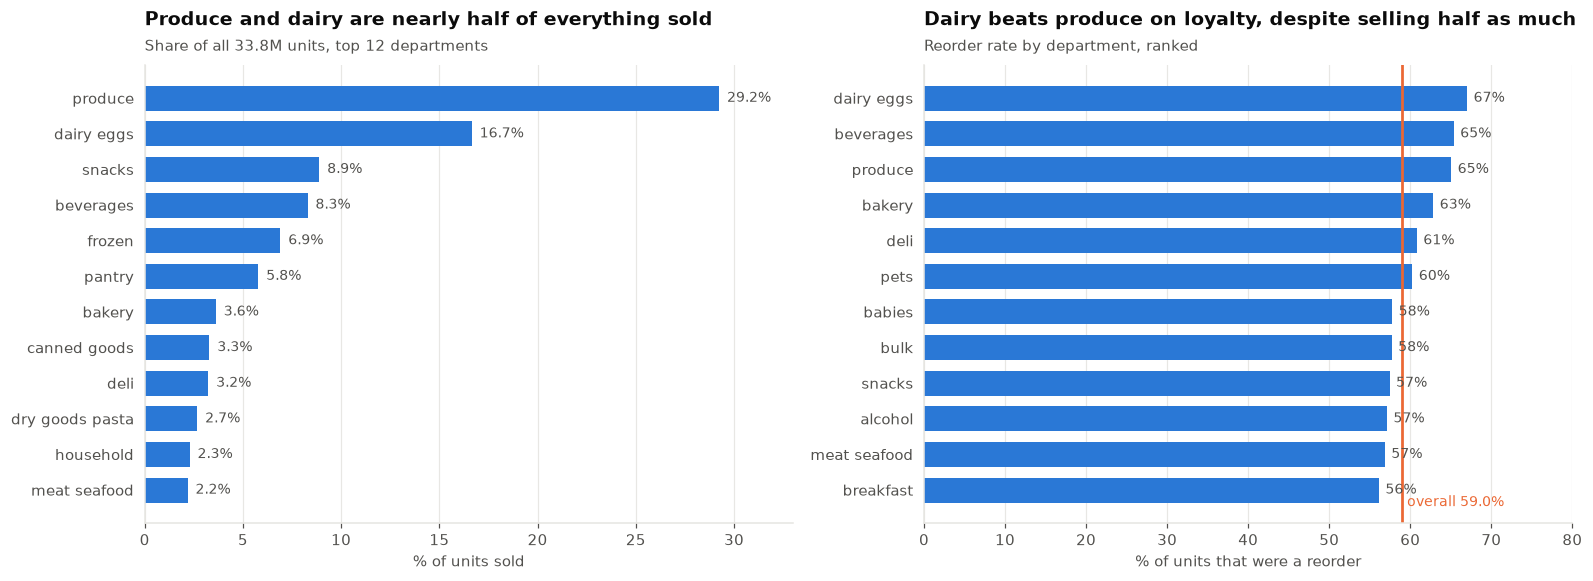

In [10]:
real = dk[~dk.is_placeholder].copy()
fig, axes = plt.subplots(1, 2, figsize=(14.6, 5.4))
t = real.head(12).iloc[::-1]
axes[0].barh(t.department, t.units_share*100, color=ic.PALETTE["s1"], height=.7)
for i, v in enumerate(t.units_share*100):
    axes[0].text(v+.4, i, f"{v:.1f}%", va="center", fontsize=9, color=ic.PALETTE["muted"])
ic.finish(axes[0], "Produce and dairy are nearly half of everything sold",
          "Share of all 33.8M units, top 12 departments", "% of units sold", "", xgrid=True)
axes[0].set_xlim(0, 33)

rr = real.sort_values("reorder_rate", ascending=False).head(12).iloc[::-1]
bars = axes[1].barh(rr.department, rr.reorder_rate*100, color=ic.PALETTE["s1"], height=.7)
avg = items.reordered.mean()*100
axes[1].axvline(avg, color=ic.PALETTE["s2"], lw=1.8)
axes[1].text(avg+.6, -.45, f"overall {avg:.1f}%", color=ic.PALETTE["s2"], fontsize=9)
for i, v in enumerate(rr.reorder_rate*100):
    axes[1].text(v+.8, i, f"{v:.0f}%", va="center", fontsize=9, color=ic.PALETTE["muted"])
ic.finish(axes[1], "Dairy beats produce on loyalty, despite selling half as much",
          "Reorder rate by department, ranked", "% of units that were a reorder", "", xgrid=True)
axes[1].set_xlim(0, 80)
fig.tight_layout(); ic.savefig(fig, "05_department_performance"); plt.show()

**Finding — volume leadership and loyalty leadership are held by different departments.**

* **Produce** is the biggest department by far: 9.89M units (**29.2%** of everything sold),
  present in **74.9%** of all baskets. Three quarters of orders contain fresh produce.
* **Dairy & eggs** sells 5.63M units (16.7%) but has the **highest reorder rate of any real
  department at 67.0%**, ahead of produce's 65.1%.
* Together, produce + dairy = **45.9%** of all units.
* At the other end: **personal care (32.2%)** and **pantry (34.7%)** have the lowest reorder
  rates, and pantry is the clearest example of the consumption-cadence effect — it appears
  in 34.8% of baskets but people do not re-buy flour and oil every week.

**Business meaning.** Produce is the *traffic* category — it is what gets the customer to
open the app. Dairy is the *habit* category — it is what brings them back on a cadence.
Those are two different roles and they justify different investment: produce quality and
availability drive acquisition and basket penetration; dairy reliability drives frequency.

In [11]:
ak = an.category_kpis(items, aisles[["aisle_id","aisle","is_placeholder"]], "aisle")
ak["basket_penetration"] = ak.aisle_id.map(an.category_penetration(items, orders, "aisle"))
ic.savetable(ak, "aisle_kpis")
real_a = ak[~ak.is_placeholder]
print("TOP 15 AISLES BY UNITS"); display(real_a.head(15)[["aisle","units","units_share","basket_penetration","reorder_rate"]]
    .style.format({"units":"{:,.0f}","units_share":"{:.1%}","basket_penetration":"{:.1%}","reorder_rate":"{:.1%}"}).hide(axis="index"))

  table  -> reports/tables/aisle_kpis.csv  (134 rows)
TOP 15 AISLES BY UNITS


aisle,units,units_share,basket_penetration,reorder_rate
fresh fruits,"3,792,661",11.2%,55.7%,71.9%
fresh vegetables,"3,568,630",10.6%,44.4%,59.5%
packaged vegetables fruits,"1,843,806",5.5%,36.7%,63.9%
yogurt,"1,507,583",4.5%,26.3%,68.7%
packaged cheese,"1,021,462",3.0%,23.0%,58.6%
milk,"923,659",2.7%,24.4%,78.2%
water seltzer sparkling water,"878,150",2.6%,19.2%,73.0%
chips pretzels,"753,739",2.2%,16.8%,58.9%
soy lactosefree,"664,493",2.0%,17.0%,69.2%
bread,"608,469",1.8%,16.4%,67.1%


  figure -> reports/figures/05_aisle_performance.png


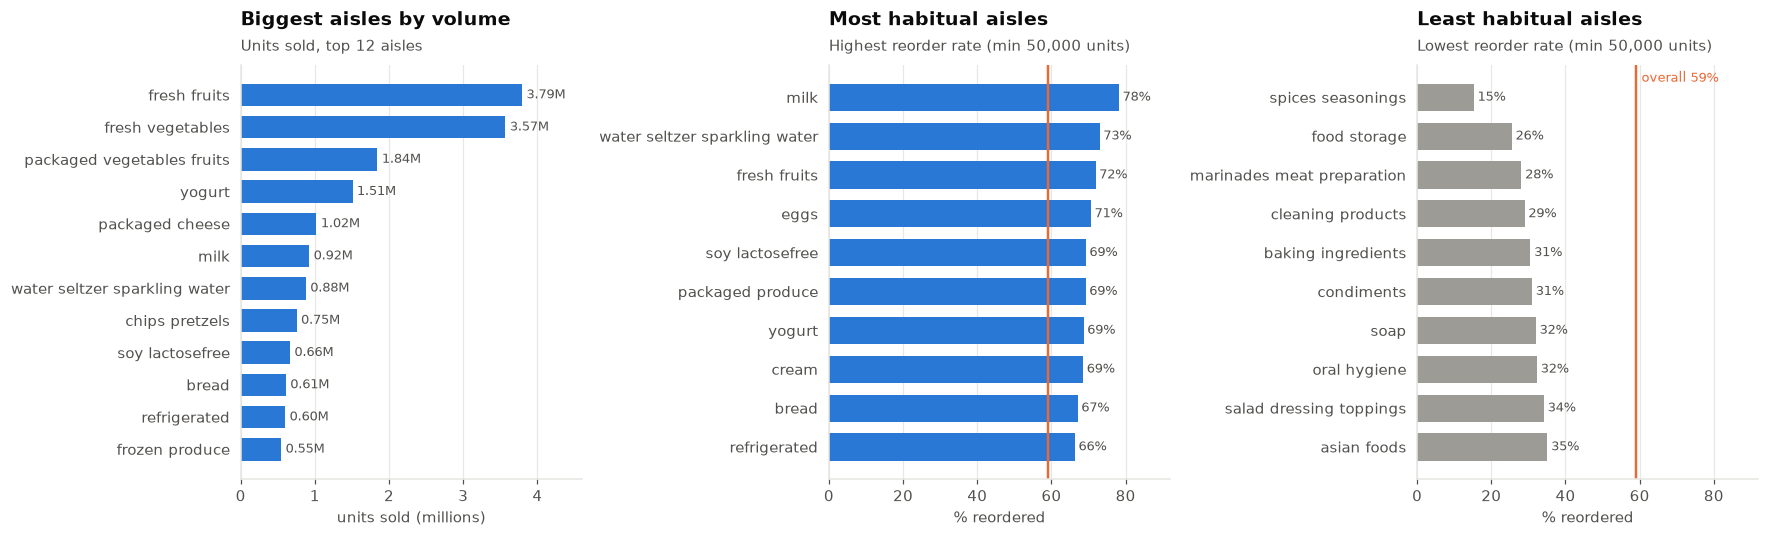

In [12]:
MIN_U = 50_000
hi = real_a[real_a.units>=MIN_U].nlargest(10,"reorder_rate")
lo = real_a[real_a.units>=MIN_U].nsmallest(10,"reorder_rate")
fig, axes = plt.subplots(1, 3, figsize=(16.2, 5.0))
t = real_a.head(12).iloc[::-1]
axes[0].barh(t.aisle, t.units/1e6, color=ic.PALETTE["s1"], height=.7)
for i, v in enumerate(t.units/1e6):
    axes[0].text(v+.06, i, f"{v:.2f}M", va="center", fontsize=8.5, color=ic.PALETTE["muted"])
ic.finish(axes[0], "Biggest aisles by volume", "Units sold, top 12 aisles", "units sold (millions)", "", xgrid=True)
axes[0].set_xlim(0, 4.6)

axes[1].barh(hi.aisle.iloc[::-1], hi.reorder_rate.iloc[::-1]*100, color=ic.PALETTE["s1"], height=.7)
for i, v in enumerate(hi.reorder_rate.iloc[::-1]*100):
    axes[1].text(v+1, i, f"{v:.0f}%", va="center", fontsize=8.5, color=ic.PALETTE["muted"])
axes[1].axvline(avg, color=ic.PALETTE["s2"], lw=1.6)
ic.finish(axes[1], "Most habitual aisles", f"Highest reorder rate (min {MIN_U:,} units)",
          "% reordered", "", xgrid=True)
axes[1].set_xlim(0, 92)

axes[2].barh(lo.aisle.iloc[::-1], lo.reorder_rate.iloc[::-1]*100, color=ic.PALETTE["neutral"], height=.7)
for i, v in enumerate(lo.reorder_rate.iloc[::-1]*100):
    axes[2].text(v+1, i, f"{v:.0f}%", va="center", fontsize=8.5, color=ic.PALETTE["muted"])
axes[2].axvline(avg, color=ic.PALETTE["s2"], lw=1.6)
axes[2].text(avg+1.5, 9.4, f"overall {avg:.0f}%", color=ic.PALETTE["s2"], fontsize=8.5)
ic.finish(axes[2], "Least habitual aisles", f"Lowest reorder rate (min {MIN_U:,} units)",
          "% reordered", "", xgrid=True)
axes[2].set_xlim(0, 92)
fig.tight_layout(); ic.savefig(fig, "05_aisle_performance"); plt.show()

**Finding.** The most popular aisle is **fresh fruits** (3.79M units, in **55.7%** of all
baskets) followed by fresh vegetables (3.57M, 44.4%). But the most *habitual* aisle is
**milk at 78.2%**, then water/seltzer (73.0%) and fresh fruits (71.9%).

The bottom of the list is just as informative: **spices & seasonings reorders at 15.3%**,
food storage 25.5%, cleaning products 29.0%, baking ingredients 30.5%. Every one of these
is a *slow-consumption* category — a jar of cumin lasts a year.

**Business meaning.** Reorder rate is close to a direct readout of how fast a category is
consumed. That makes it a planning input, not a scorecard: milk, water and fresh fruit are
where replenishment automation pays off, while spices and cleaning products need
*reminder* mechanics on a multi-month cycle — and should never be judged against the
59% average.

## 5.4 Phase 9 — Reorder behaviour

The brief's five questions, answered in order.

In [13]:
q1 = items.reordered.mean()
q1b = items[items.order_number>1].reordered.mean()
print(f"Q1. What percentage of items are reorders?")
print(f"    {q1*100:.2f}% of all 33.8M basket lines.")
print(f"    {q1b*100:.2f}% once first orders — which cannot contain a reorder by definition — are excluded.")

Q1. What percentage of items are reorders?
    59.01% of all 33.8M basket lines.
    62.87% once first orders — which cannot contain a reorder by definition — are excluded.


In [14]:
print("\nQ2. Which products are bought again most often?")
display(pk.nlargest(8,"reorders")[["product_name","department","reorders","purchases","reorder_rate","n_customers"]]
        .style.format({"reorders":"{:,.0f}","purchases":"{:,.0f}","reorder_rate":"{:.1%}","n_customers":"{:,.0f}"}).hide(axis="index"))
print("By rate rather than count, with a 2,000-purchase floor:")
display(pk[pk.purchases>=2000].nlargest(8,"reorder_rate")[["product_name","department","purchases","reorder_rate"]]
        .style.format({"purchases":"{:,.0f}","reorder_rate":"{:.1%}"}).hide(axis="index"))


Q2. Which products are bought again most often?


product_name,department,reorders,purchases,reorder_rate,n_customers
Banana,produce,"415,166","491,291",84.5%,"76,125"
Bag of Organic Bananas,produce,"329,275","394,930",83.4%,"65,655"
Organic Strawberries,produce,"214,448","275,577",77.8%,"61,129"
Organic Baby Spinach,produce,"194,939","251,705",77.4%,"56,766"
Organic Hass Avocado,produce,"176,173","220,877",79.8%,"44,704"
Organic Avocado,produce,"140,270","184,224",76.1%,"43,954"
Organic Whole Milk,dairy eggs,"127,178","152,915",83.2%,"25,048"
Large Lemon,produce,"112,178","160,792",69.8%,"48,614"


By rate rather than count, with a 2,000-purchase floor:


product_name,department,purchases,reorder_rate
Half And Half Ultra Pasteurized,dairy eggs,"2,995",86.1%
Whole Organic Omega 3 Milk,dairy eggs,"9,410",86.0%
Organic Lactose Free Whole Milk,dairy eggs,"8,742",85.9%
Organic Homogenized Whole Milk,dairy eggs,"4,095",85.8%
"Milk, Organic, Vitamin D",dairy eggs,"20,770",85.5%
Organic Reduced Fat Milk,dairy eggs,"36,869",85.2%
Goat Milk,dairy eggs,"5,353",85.0%
Banana,produce,"491,291",84.5%


In [15]:
print("\nQ3. Which department has the highest reorder rate?")
display(real.sort_values("reorder_rate", ascending=False).head(5)[["department","units","reorder_rate","basket_penetration"]]
        .style.format({"units":"{:,.0f}","reorder_rate":"{:.1%}","basket_penetration":"{:.1%}"}).hide(axis="index"))


Q3. Which department has the highest reorder rate?


department,units,reorder_rate,basket_penetration
dairy eggs,"5,631,067",67.0%,67.7%
beverages,"2,804,175",65.4%,45.4%
produce,"9,888,378",65.1%,74.9%
bakery,"1,225,181",62.8%,27.4%
deli,"1,095,540",60.8%,24.0%


In [16]:
print("\nQ4. Does reorder behaviour differ by how many orders a customer has placed?")
rt = an.reorder_by_customer_tenure(items, customers)
rt["bucket"] = pd.Categorical(rt.bucket, ["3-4 orders","5-6","7-10","11-20","21-50","51-100"], ordered=True)
rt = rt.sort_values("bucket")
ic.savetable(rt, "reorder_by_customer_tenure")
display(rt.style.format({"items":"{:,.0f}","reorders":"{:,.0f}","customers":"{:,.0f}",
                         "distinct_products":"{:,.0f}","reorder_rate":"{:.1%}"}).hide(axis="index"))


Q4. Does reorder behaviour differ by how many orders a customer has placed?


  table  -> reports/tables/reorder_by_customer_tenure.csv  (6 rows)


bucket,items,reorders,customers,distinct_products,reorder_rate
3-4 orders,"837,156","200,762","23,986","34,940",24.0%
5-6,"1,776,941","547,777","35,755","40,544",30.8%
7-10,"3,535,396","1,412,608","44,772","44,644",40.0%
11-20,"7,359,875","3,782,180","50,965","47,433",51.4%
21-50,"12,850,710","8,405,902","39,821","47,844",65.4%
51-100,"7,459,028","5,606,131","10,910","41,813",75.2%


  table  -> reports/tables/reorder_by_order_number.csv  (50 rows)
  figure -> reports/figures/05_reorder_behaviour.png


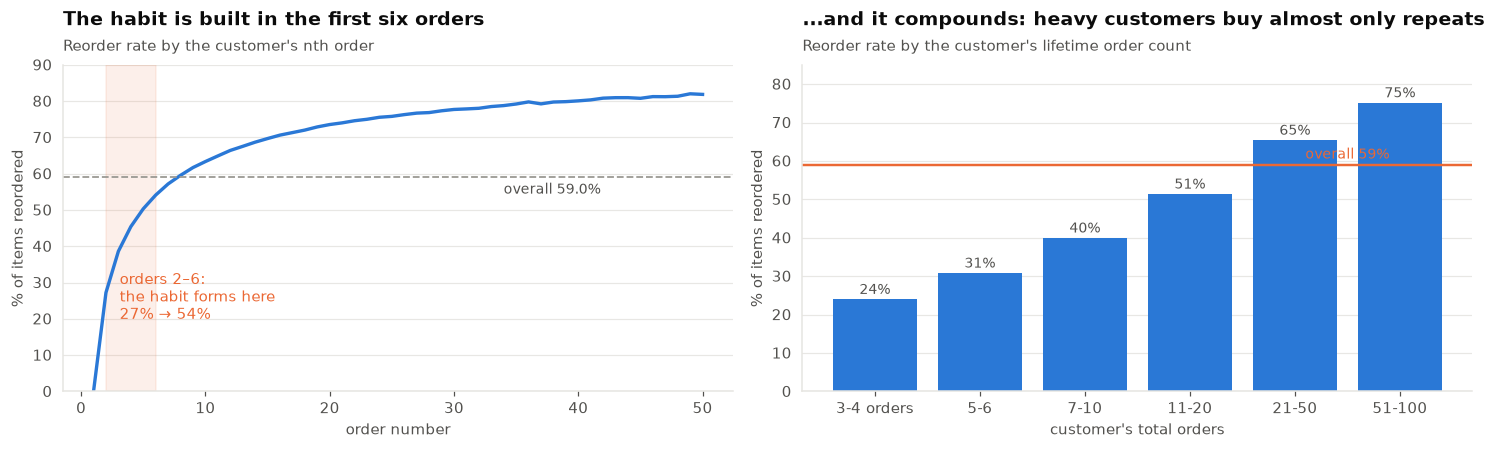

In [17]:
ron = an.reorder_by_order_number(items, cap=50); ic.savetable(ron, "reorder_by_order_number")
fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.2))
axes[0].plot(ron.order_number, ron.reorder_rate*100, color=ic.PALETTE["s1"], lw=2.2)
axes[0].axhline(q1*100, color=ic.PALETTE["neutral"], ls="--", lw=1.2)
axes[0].axvspan(2, 6, color=ic.PALETTE["s2"], alpha=.10)
axes[0].text(3.1, 20, "orders 2–6:\nthe habit forms here\n27% → 54%", fontsize=9.5, color=ic.PALETTE["s2"])
axes[0].text(34, q1*100-4.5, "overall 59.0%", color=ic.PALETTE["muted"], fontsize=9)
ic.finish(axes[0], "The habit is built in the first six orders",
          "Reorder rate by the customer's nth order", "order number", "% of items reordered")
axes[0].set_ylim(0, 90)

axes[1].bar(rt.bucket.astype(str), rt.reorder_rate*100, color=ic.PALETTE["s1"])
axes[1].axhline(q1*100, color=ic.PALETTE["s2"], lw=1.6)
axes[1].text(4.1, q1*100+1.6, f"overall {q1*100:.0f}%", color=ic.PALETTE["s2"], fontsize=9)
for i, v in enumerate(rt.reorder_rate*100):
    axes[1].text(i, v+1.4, f"{v:.0f}%", ha="center", fontsize=9, color=ic.PALETTE["muted"])
ic.finish(axes[1], "...and it compounds: heavy customers buy almost only repeats",
          "Reorder rate by the customer's lifetime order count", "customer's total orders", "% of items reordered")
axes[1].set_ylim(0, 85)
fig.tight_layout(); ic.savefig(fig, "05_reorder_behaviour"); plt.show()

**Q4 answer — yes, dramatically, and the shape is the useful part.**

Reorder rate rises from **0% at order 1** (structurally impossible) to **27.2% at order 2**,
**54.1% at order 6**, **63.4% at order 10**, and **81.9% by order 50**. By lifetime order
count the spread is 24.0% (3–4 orders) to **75.2%** (51–100 orders).

The steepest climb is between orders **2 and 6** — the curve gains 27 percentage points
there and then flattens. **That is the habit-formation window.** A customer who reaches
their sixth order is behaving like a retained customer; one who stalls at three is not.
This is the single most actionable timing finding in the project, because it says *when*
intervention is worth paying for.

Note too that heavy customers do not merely repeat — they also *explore* more in absolute
terms (169.8 distinct products for 51–100 order customers vs 26.5 for 3–4 order customers).
Repetition and breadth grow together; they are not a trade-off.

In [18]:
print("\nQ5. Which products combine high volume AND high reorder rate?")
core = q[q.quadrant=="Core staples (high volume + high loyalty)"].nlargest(15,"purchases")
display(core[["product_name","department","purchases","n_customers","reorder_rate"]]
        .style.format({"purchases":"{:,.0f}","n_customers":"{:,.0f}","reorder_rate":"{:.1%}"}).hide(axis="index"))
print(f"{len(q[q.quadrant.str.startswith('Core')]):,} products qualify as core staples.")
print(f"They are {len(q[q.quadrant.str.startswith('Core')])/items.product_uid.nunique()*100:.1f}% of purchased products "
      f"and {q[q.quadrant.str.startswith('Core')].purchases.sum()/len(items)*100:.1f}% of all units sold.")


Q5. Which products combine high volume AND high reorder rate?


product_name,department,purchases,n_customers,reorder_rate
Banana,produce,"491,291","76,125",84.5%
Bag of Organic Bananas,produce,"394,930","65,655",83.4%
Organic Strawberries,produce,"275,577","61,129",77.8%
Organic Baby Spinach,produce,"251,705","56,766",77.4%
Organic Hass Avocado,produce,"220,877","44,704",79.8%
Organic Avocado,produce,"184,224","43,954",76.1%
Large Lemon,produce,"160,792","48,614",69.8%
Organic Whole Milk,dairy eggs,"152,915","25,048",83.2%
Strawberries,produce,"149,445","44,857",70.0%
Limes,produce,"146,660","46,658",68.2%


2,537 products qualify as core staples.
They are 5.1% of purchased products and 60.2% of all units sold.


## 5.5 Reorder rate is a cadence meter, not a satisfaction score

This is the most important interpretive point in the notebook, so it is tested rather than
asserted. If reorder rate mostly measured *satisfaction*, it would vary freely within a
category according to brand quality. If it mostly measures *how fast the product is used
up*, then knowing a product's category should predict much of its reorder rate. We can
measure exactly how much, with a variance decomposition:

In [19]:
cat_spread = (q.groupby("department").reorder_rate.agg(["count","mean","std"])
              .query("count >= 100").sort_values("mean", ascending=False))
display(cat_spread.style.format({"count":"{:,.0f}","mean":"{:.1%}","std":"{:.1%}"}))

# Variance decomposition (eta-squared): how much of a product's reorder rate is explained
# by which category it sits in? Comparing standard deviations would not answer this —
# it ignores how far apart the category means are relative to the overall spread.
y = q.reorder_rate; grand = y.mean(); ss_tot = ((y - grand)**2).sum()
def eta2(col):
    g = q.groupby(col).reorder_rate
    return float((g.count() * (g.mean() - grand)**2).sum() / ss_tot)
e_dept, e_aisle = eta2("department"), eta2("aisle")
print(f"\nVariance in product reorder rate explained by DEPARTMENT: {e_dept*100:.1f}%  (eta-squared, 21 groups)")
print(f"Variance explained by AISLE:                              {e_aisle*100:.1f}%  (133 groups)")
print(f"Left unexplained by category (i.e. product-specific):      {(1-e_aisle)*100:.1f}%")

,count,mean,std
department,,,
dairy eggs,"1,219",61.9%,11.5%
beverages,860,61.6%,11.9%
bakery,429,60.4%,10.3%
babies,200,58.2%,8.0%
deli,330,58.0%,9.4%
snacks,"1,172",56.6%,9.4%
breakfast,314,55.4%,9.1%
produce,737,52.7%,11.2%
frozen,865,52.7%,9.4%



Variance in product reorder rate explained by DEPARTMENT: 40.5%  (eta-squared, 21 groups)
Variance explained by AISLE:                              56.3%  (133 groups)
Left unexplained by category (i.e. product-specific):      43.7%


**Finding — category explains most of a product's reorder rate, but not all of it.**
Which *aisle* a product sits in accounts for **56.3%** of the variance in its reorder rate,
and department alone for **40.5%**. Within a department the spread is still real
(pantry products range from 10% to 80%), so category is a strong prior, not a verdict.

**Business meaning.** Two rules follow. First, **benchmark a product against its own
category, never against the overall 59%** — an olive oil at 48% is performing well for
pantry (mean 32.9%), while a milk at 60% is performing badly for dairy (mean 61.9%).
Second, because category is a strong prior, reorder rate is best read as *consumption
cadence*: the categories at the top (dairy 61.9%, beverages 61.6%, bakery 60.4%) are the
fast-consumed ones, and those at the bottom (pantry 32.9%, international 35.9%, personal
care 38.1%) are the slow-consumed ones. The residual 44% is where genuine product-level
preference lives, and that is the part worth investigating per SKU.

## 5.6 Phase 7–9 summary

| Question | Answer |
|---|---|
| Top product by volume | Banana — 491,291 units, bought by 37% of all customers |
| Top product by reorders | Banana — 415,166 repeat purchases |
| Highest reorder rate (≥2,000 purchases) | Half & Half Ultra Pasteurized, 86.1% — the top 9 are all milk |
| Biggest department | Produce — 29.2% of units, in 74.9% of baskets |
| Most habitual department | Dairy & eggs — 67.0% reorder rate |
| Most popular aisle | Fresh fruits — 3.79M units, in 55.7% of baskets |
| Most habitual aisle | Milk — 78.2% |
| Least habitual aisle | Spices & seasonings — 15.3% |
| % of items that are reorders | 59.0% overall, 62.9% excluding first orders |
| Does reorder differ by customer tenure | Yes: 24.0% (3–4 orders) → 75.2% (51–100 orders) |
| High volume + high reorder | 2,537 products; 67.5% of units in the ≥500-purchase pool |

Carried into the recommendations: the **core-staples list** (availability), the
**milk/yogurt replenishment cluster** (subscription), the **orders 2–6 habit window**
(retention timing), and the rule that **reorder rate must be benchmarked within its category**.